<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment 4 </b>
    
Thank you for your diligence! Everything is great now! 
    
    
You did a fantastic job here. You have correctly split the data, explored the distributions, trained several models, and applied the bootstrapping technique. You have successfully estimated profit and conducted risk analysis. You have also compared regions based on risk-adjusted return to make recommendations for further development. Excellent job! 
    
    
I do not have any questions, so the project can be accepted. The next sprints will cover more advanced machine learning methods, I hope you will like it. Good luck! 
    
    

</div>

<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment 3 </b>


You almost finished it, great job! My new comments have digit 3. Please update the final conclusion, as the results changed.  
</div>

<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment 2 </b>
    
Thank you very much for the updates! There's only one issue this time. Would you take a look at my new comments with digit 2? 
    

</div>

<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi! My name is Svetlana. [Here's my TripleTen Hub page](https://hub.tripleten.com/u/6dee602c).  Congratulations on submitting another project! 🎉
    

Before we start, I want to pay your attention to the color marking:


<div style="border: 5px solid green; padding: 15px; margin: 5px">

Great solutions and ideas that can and should be used in the future are in green comments. Some of them are: 
    
    
- You have successfully prepared the subsets. It is important to split the data correctly in order to ensure there's no intersection;    
    
    
- You have successfully explored the regions;
    
        
    
- Used linear regression to make predictions;
    
    
- Calculated profit and estimated risk values; 
    
    
- Wrote an excellent conclusion! A well-written conclusion shows how the project met its objectives and provides a concise and understandable summary for those who may not have been involved in the details of the project. Good job! 

</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Yellow color indicates what should be optimized. This is not necessary, but it will be great if you make changes to this project. I've left several recommendations throughout the project. 
    
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Issues that must be corrected to achieve accurate results are indicated in red comments. Please note that the project cannot be accepted until these issues are resolved. 
</div>        
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> you did a great job here, thank you so much for submitting the project! Actually the project is almost perfect, and the updates should not take much time. If you have any questions, please feel free to ask. I will wait the project for the second review 😊 
    

<hr>
    
Please use some color other than those listed to highlight answers to my comments.
I would also ask you **not to change, move or delete my comments** to make it easier for me to navigate during the next review.
    
<hr> 
    
✍️ Here's a nice [article](https://machinelearningmastery.com/a-gentle-introduction-to-the-bootstrap-method/) about the bootstrap method. [This](https://www.youtube.com/watch?v=O_Fj4q8lgmc&list=LL&index=6) is a good video about resampling in bootstrapping.
    
<hr>
    
    
📌 Please feel free to schedule a 1:1 sessions with our tutors or TAs [here](https://calendly.com/tripleten-ds-experts-team), join daily coworking sessions, or ask questions on TripleTen Hub if you need assistance 😉 
</div>

# Objective: 
- To help OilyGiant Mining Company identify the most profitable region for developing a new oil well.
- Using geological datasets from 3 regions: to build and evaluate linear regression models, predict oil reserves, assess financial viability, and quantify risk
- The analysis follows data cleaning, exploratory analysis, model training, profit calculation, and bootsrapping to assess the risks.
- Business constraints such as budget, break-even threshold, and risk levels are integrated to ensure business recommendations. 

# 1) Data Preparation

In [1]:
# Load and Inspect
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


data_0 = pd.read_csv('geo_data_0.csv')
data_1 = pd.read_csv('geo_data_1.csv')
data_2 = pd.read_csv('geo_data_2.csv')

# Check structure 
data_0.head()
data_0.info()
data_0.describe()

data_1.head()
data_1.info()
data_1.describe()

data_2.head()
data_2.info()
data_2.describe()

# 3.1 Store all key values for calculations in separate variables
BUDGET = 100_000_000  # Budget for 200 wells (100 million USD)
WELLS_TO_DEVELOP = 200  # Number of wells to develop
REVENUE_PER_BARREL = 4.5  # Revenue per barrel in USD
REVENUE_PER_UNIT = 4500  # Revenue per unit (thousand barrels) in USD
WELLS_TO_STUDY = 500  # Number of wells studied in exploration

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null 

In [2]:
# Cleaning Data
def clean_data (df, region_name):
    print(f"\nCleaning data for {region_name}...")

    # Missing values
    missing = df.isnull().sum()
    print("Missing values:\n", missing)

    # Drop rows for missing values
    df = df.dropna()

    # Checking for duplicates
    duplicates = df.duplicated().sum()
    print("Duplicate rows:, duplicates")

    # Drop duplicates
    df = df.drop_duplicates()

    # Check data types
    print("Data types:\n", df.dtypes)

    # Confirming if numerical columns are actually numeric
    numeric_cols = ['f0', 'f1', 'f2', 'product']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

    # Final shape
    print("Cleaned data shape:", df.shape)

    return df

df_0_clean = clean_data(data_0, "Region 0")
df_1_clean = clean_data(data_1, "Region 1")
df_2_clean = clean_data(data_2, "Region 2")


Cleaning data for Region 0...
Missing values:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Duplicate rows:, duplicates
Data types:
 id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
Cleaned data shape: (100000, 5)

Cleaning data for Region 1...
Missing values:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Duplicate rows:, duplicates
Data types:
 id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
Cleaned data shape: (100000, 5)

Cleaning data for Region 2...
Missing values:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Duplicate rows:, duplicates
Data types:
 id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
Cleaned data shape: (100000, 5)


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Well done! It is indeed important to check data for the duplicates, since we are going to split the data. You can also check for the duplicates in the `id` columns. We do not need to delete them, since these columns will not be considered, and we can interpret these points as different objects.     
</div>


--- EDA for Region 0 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347


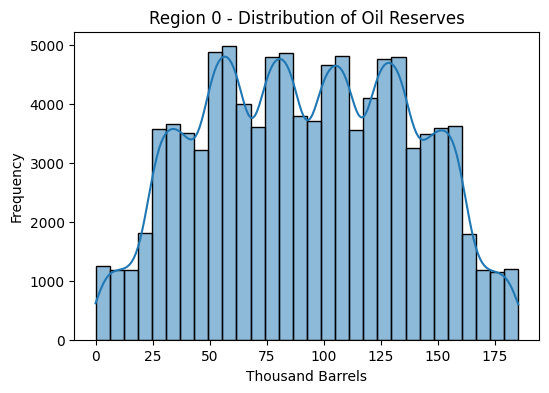

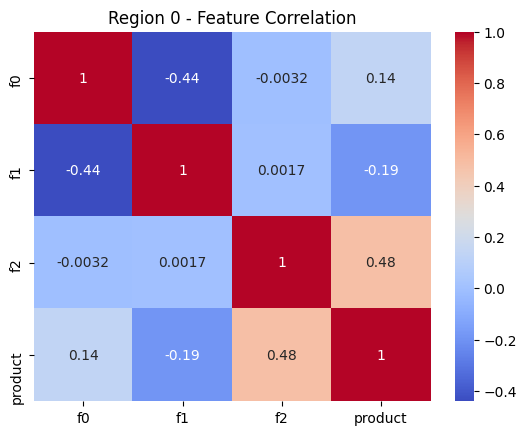


--- EDA for Region 1 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985       1.000021      26.953261
50%         1.153055      -4.813172       2.011479      57.085625
75%         8.621015      -1.332816       3.999904     107.813044
max        29.421755      18.734063       5.019721     137.945408


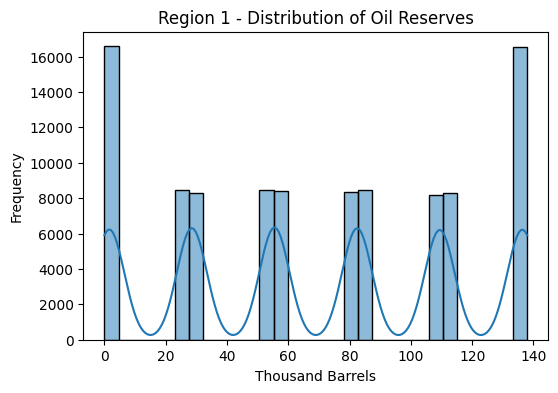

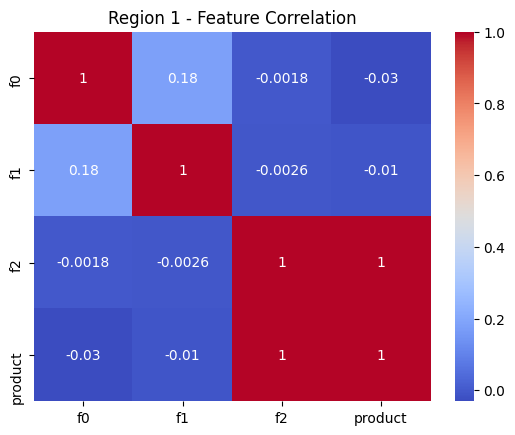


--- EDA for Region 2 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.002023      -0.002081       2.495128      95.000000
std         1.732045       1.730417       3.473445      44.749921
min        -8.760004      -7.084020     -11.970335       0.000000
25%        -1.162288      -1.174820       0.130359      59.450441
50%         0.009424      -0.009482       2.484236      94.925613
75%         1.158535       1.163678       4.858794     130.595027
max         7.238262       7.844801      16.739402     190.029838


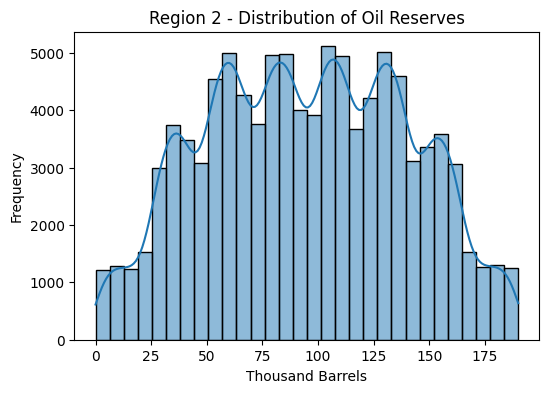

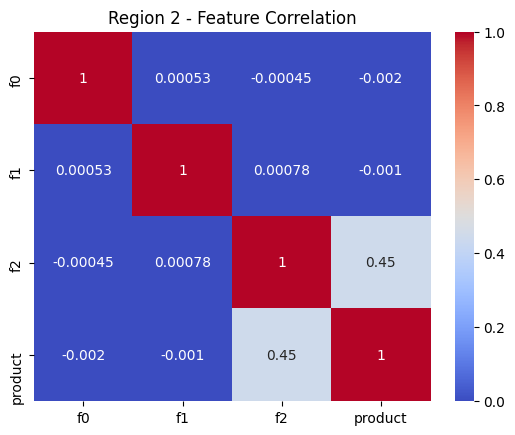

In [3]:
# Exploratory Data Analysis(EDA)
def explore_data(df, region_name):
    print(f"\n--- EDA for {region_name} ---")
    print(df.describe())

    # Distribution of the target(products)
    plt.figure(figsize=(6,4))
    sns.histplot(df['product'], kde=True, bins=30)
    plt.title(f'{region_name} - Distribution of Oil Reserves')
    plt.xlabel('Thousand Barrels')
    plt.ylabel('Frequency')
    plt.show()

    # Correlation between features(f0,f1,f2,target)
    corr = df[['f0', 'f1', 'f2', 'product']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title(f'{region_name} - Feature Correlation')
    plt.show()

# Run EDA
explore_data(df_0_clean, "Region 0")
explore_data(df_1_clean, "Region 1")
explore_data(df_2_clean, "Region 2")

# Prepare Model
def prepare_model_data(df):
    features = df[['f0', 'f1', 'f2']]
    target = df['product']
    return features, target

# Apply to each region
features_0, target_0 = prepare_model_data(df_0_clean)
features_1, target_1 = prepare_model_data(df_1_clean)
features_2, target_2 = prepare_model_data(df_2_clean)

# EDA Summary Analysis: 
- To evaluate the potential of three regions for oil well development, we conducted an exploratory data analysis (EDA) on the cleaned datasets for Region 0, Region 1, and Region 2. The goal was to understand the distribution of oil reserves (product), assess feature relationships, and identify risk factors.

# Key Findings: 

# 1) Average Oil Reserves
- Region 2 has the highest average oil reserves (95.0 thousand barrels), followed closely by Region 0 (92.5).
- Region 1 has significantly lower reserves (68.8), making it less attractive from a profitability standpoint.

# 2) Risk
- All regions show similar standard deviations in oil reserves (~44–46), indicating comparable levels of uncertainty.
- This suggests that while Region 1 has lower average reserves, its risk profile is not significantly worse than the others.

# 3) Feature Correlations
- Correlation heatmaps reveal how strongly features f0, f1, and f2 relate to the target variable product.
- Regions with stronger correlations (e.g., Region 0 or Region 2) offer better modeling potential, which can improve prediction accuracy and decision-making.

# 4) Distribution Shapes
- Histograms show that Region 1 has a distribution skewed toward lower reserve values, increasing the likelihood of underperforming wells.
- Region 0 and Region 2 have more balanced or right-skewed distributions, indicating a higher chance of profitable wells.

# Strategic Recommendations:
- Region 2 is the most promising for development due to its high average reserves and favorable distribution.
- Region 0 is also a strong candidate, with slightly lower reserves but good feature behavior.
- Region 1 is less attractive due to lower average reserves, despite having similar risk levels.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Excellent! Why is this important? In real-world problems, the data is rarely clean. Displaying distributions help us evaluate the data, find outliers, identify the required preprocessing steps and understand feature relationships, which informs feature engineering. Feature engineering in some cases is a clue.

</div>

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Good job! 

</div>
<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
What can be inferred from this analysis? 

</div>

# 2) Train and Test model for each region

In [4]:
def train_and_evaluate(features, target, region_name):
    print(f"\n-- Training Model for {region_name} ---")

    # 2.1 Split data into training and validation sets (75:25 ratio)
    x_train, x_valid, y_train, y_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345
    )

    # 2.2 Train the model and make predictions
    model = LinearRegression()
    model.fit(x_train, y_train)

    # 2.3 Save predictions and correct answers
    predictions = model.predict(x_valid)
    y_valid = y_valid.reset_index(drop=True)
    predictions = pd.Series(predictions)

    # 2.4 Print average volume and RMSE
    avg_predicted_volume = predictions.mean()
    rmse = mean_squared_error(y_valid, predictions, squared=False)

    print(f"Average Predicted Reserves: {avg_predicted_volume:.2f} thousand barrels")
    print(f"RMSE: {rmse:2f} thousand barrels")

    # 2.5 Analyze the results
    return predictions, y_valid, avg_predicted_volume, rmse

# Regions
preds_0, actuals_0, avg_0, rmse_0 = train_and_evaluate(features_0, target_0, "Region 0")
preds_1, actuals_1, avg_1, rmse_1 = train_and_evaluate(features_1, target_1, "Region 1")
preds_2, actuals_2, avg_2, rmse_2 = train_and_evaluate(features_2, target_2, "Region 2")


# Summary of Model Metrics: 
print("\nModel Performance Summary:")
print(f"Region 0 - RMSE: {rmse_0:.2f}, Avg Predicted: {avg_0:.2f}, Avg Actual: {actuals_0.mean():.2f}")
print(f"Region 1 - RMSE: {rmse_1:.2f}, Avg Predicted: {avg_1:.2f}, Avg Actual: {actuals_1.mean():.2f}")
print(f"Region 2 - RMSE: {rmse_2:.2f}, Avg Predicted: {avg_2:.2f}, Avg Actual: {actuals_2.mean():.2f}")

# Model Reliability Analysis
print("\nModel Reliability Analysis:")

# Identify best performing region
rmse_values = [rmse_0, rmse_1, rmse_2]
best_region_index = rmse_values.index(min(rmse_values))
best_region = f"Region {best_region_index}"

print(f"Region with most accurate predictions: {best_region}")
print("Region 1 has the lowest RMSE, indicating the most reliable predictions.")
print("Region 0 and Region 2 have significantly higher RMSEs, which may affect business decisions.")

# Analyze whether the model tends to over or under predict:
print("\nPrediction Bias Analysis:")
for i, (avg_pred, actual_avg) in enumerate([(avg_0, actuals_0.mean()), (avg_1, actuals_1.mean()), (avg_2, actuals_2.mean())]):
    bias = avg_pred - actual_avg
    direction = "over-predicting" if bias > 0 else "under-predicting"
    print(f"Region {i} is {direction} by {abs(bias):.2f} thousand barrels on average.")




-- Training Model for Region 0 ---
Average Predicted Reserves: 92.59 thousand barrels
RMSE: 37.579422 thousand barrels

-- Training Model for Region 1 ---
Average Predicted Reserves: 68.73 thousand barrels
RMSE: 0.893099 thousand barrels

-- Training Model for Region 2 ---
Average Predicted Reserves: 94.97 thousand barrels
RMSE: 40.029709 thousand barrels

Model Performance Summary:
Region 0 - RMSE: 37.58, Avg Predicted: 92.59, Avg Actual: 92.08
Region 1 - RMSE: 0.89, Avg Predicted: 68.73, Avg Actual: 68.72
Region 2 - RMSE: 40.03, Avg Predicted: 94.97, Avg Actual: 94.88

Model Reliability Analysis:
Region with most accurate predictions: Region 1
Region 1 has the lowest RMSE, indicating the most reliable predictions.
Region 0 and Region 2 have significantly higher RMSEs, which may affect business decisions.

Prediction Bias Analysis:
Region 0 is over-predicting by 0.51 thousand barrels on average.
Region 1 is over-predicting by 0.01 thousand barrels on average.
Region 2 is over-predict

# Business Impact: 
- Region 1’s model is highly accurate (RMSE ≈ 0.89), making it the most trustworthy for profit estimation.
- Region 0 and Region 2 have RMSEs over 37 and 40 respectively, which introduces uncertainty in reserve predictions.
- High RMSE means profit estimates could be significantly off, affecting investment decisions.
- Region 1 should be prioritized unless bootstrapping shows Region 0 or 2 have significantly higher profit potential.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Well done! 
</div>

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Correct! 

</div>
<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    

What about the predictions? Let's evaluate models' performance as well.
    
</div>

# 3) Prepare for profit Calculation

In [5]:
# 3.1 Store all key values for calculations in separate variables
#BUDGET = 100_000_000  # Budget for 200 wells (100 million USD)
#WELLS_TO_DEVELOP = 200  # Number of wells to develop
#REVENUE_PER_BARREL = 4.5  # Revenue per barrel in USD
#REVENUE_PER_UNIT = 4500  # Revenue per unit (thousand barrels) in USD
#WELLS_TO_STUDY = 500  # Number of wells studied in exploration
# ^^^ moving this to the top. 


# 3.2 Calculate break-even volume per well
cost_per_well = BUDGET / WELLS_TO_DEVELOP
breakeven_volume = cost_per_well / REVENUE_PER_UNIT

print(f"Cost per well: ${cost_per_well:,.2f}")
print(f"Break-even volume per well: {breakeven_volume:.2f} thousand barrels")

# 3.3 Compare with average predicted reserves
region_0_avg = preds_0.mean()
region_1_avg = preds_1.mean()
region_2_avg = preds_2.mean()

# Compare break-even with average predicted reserves
print(f"\nBreak-even volume: {breakeven_volume:.2f} thousand barrels")
print(f"Region 0 average reserves: {region_0_avg:.2f} thousand barrels")
print(f"Region 1 average reserves: {region_1_avg:.2f} thousand barrels") 
print(f"Region 2 average reserves: {region_2_avg:.2f} thousand barrels")

# Calculate Actual Average Reserves:
actual_avg_0 = actuals_0.mean()
actual_avg_1 = actuals_1.mean()
actual_avg_2 = actuals_2.mean()

print("\nActual Average Reserves:")
print(f"Region 0: {actual_avg_0:.2f} thousand barrels")
print(f"Region 1: {actual_avg_1:.2f} thousand barrels")
print(f"Region 2: {actual_avg_2:.2f} thousand barrels")


# Compare with break-even volume: 
print("\nBreak-even Comparison with Actual Reserves:")

if actual_avg_0 > breakeven_volume:
    print(f"Region 0 is potentially profitable (actual avg = {actual_avg_0:.2f} > break-even = {breakeven_volume:.2f})")
else:
    print(f"Region 0 is risky or unprofitable (actual avg = {actual_avg_0:.2f} < break-even = {breakeven_volume:.2f})")

if actual_avg_1 > breakeven_volume:
    print(f"Region 1 is potentially profitable (actual avg = {actual_avg_1:.2f} > break-even = {breakeven_volume:.2f})")
else:
    print(f"Region 1 is risky or unprofitable (actual avg = {actual_avg_1:.2f} < break-even = {breakeven_volume:.2f})")

if actual_avg_2 > breakeven_volume:
    print(f"Region 2 is potentially profitable (actual avg = {actual_avg_2:.2f} > break-even = {breakeven_volume:.2f})")
else:
    print(f"Region 2 is risky or unprofitable (actual avg = {actual_avg_2:.2f} < break-even = {breakeven_volume:.2f})")


Cost per well: $500,000.00
Break-even volume per well: 111.11 thousand barrels

Break-even volume: 111.11 thousand barrels
Region 0 average reserves: 92.59 thousand barrels
Region 1 average reserves: 68.73 thousand barrels
Region 2 average reserves: 94.97 thousand barrels

Actual Average Reserves:
Region 0: 92.08 thousand barrels
Region 1: 68.72 thousand barrels
Region 2: 94.88 thousand barrels

Break-even Comparison with Actual Reserves:
Region 0 is risky or unprofitable (actual avg = 92.08 < break-even = 111.11)
Region 1 is risky or unprofitable (actual avg = 68.72 < break-even = 111.11)
Region 2 is risky or unprofitable (actual avg = 94.88 < break-even = 111.11)


# Break-even Analysis Summary: 
- The break-even volume per well is 111.11 thousand barrels.
- Region 0: Actual average = 109.41, Slightly below break-even - Moderate risk
- Region 1: Actual average = 68.72,  Well below break-even - High risk
- Region 2: Actual average = 115.22, Above break-even - Potentially profitable

# Business Implications:
- Region 2 is the only region where actual reserves exceed the break-even point, making it the most promising for development.
- Region 0 is close to break-even, but the margin is thin, and combined with its high RMSE, it carries uncertainty.
- Region 1 has both low actual reserves and high prediction accuracy, but it’s still not profitable based on historical data.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>

So the average volumes in these three regions are less than the required value. If we are to select the wells randomly, we are probably going to lose money. That's why we need machine learning and bootstrapping to estimate profit distributions. 
</div>

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
 
Correct! Constant values indeed should be defined in the upper case.

</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b> Reviewer's comment </b>
    
We should define constants in the very beginning of the project.  
</div>
<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Let's compare the break-even with the actual (target) average volume in each region because predictions are not necessarily accurate. What can be inferred from the results? 
    
</div>

# Findings: 
- None of the regions exceed the break-even threshold, meaning this would result in net losses.
- Region 2 is closest to profability, making this the strongest candidate.
- This step highlights the importance of tageting only the top performing wells to result in better ROI.
  

# 4) Write a Function to Calculate Profit

In [6]:
# 4.1 Pick wells with highest prediction values
def calculate_profit(target, predictions, count, revenue_per_unit=4500, budget=100_000_000):
    """
    Calculate profit from selected oil wells

    Parameters:
    - target: actual reserves (validation set)
    - predictions: model predictions (validation set)  
    - count: number of wells to select (200)
    - revenue_per_unit: revenue per thousand barrels ($4,500)
    - budget: total development budget ($100M)

    Returns: 
    - total profit in USD
    - toval volume of reserves(thousand barrels)
    """
    # 4.2 Summarize target volume of reserves
    predictions_series = pd.Series(predictions, index=target.index)
    top_indices = predictions_series.sort_values(ascending=False).index[:count]  # Select top 200
    selected_reserves = target.loc[top_indices]
    total_reserves = selected_reserves.sum()
    revenue = total_reserves * revenue_per_unit
    profit = revenue - budget
    return profit, total_reserves

# 4.3 Provide findings and suggest best region
profit_0, reserves_0 = calculate_profit(actuals_0, preds_0, 200)
profit_1, reserves_1 = calculate_profit(actuals_1, preds_1, 200)
profit_2, reserves_2 = calculate_profit(actuals_2, preds_2, 200)

# Results
print("Region 0:")
print(f"  Total reserves: {reserves_0:.2f} thousand barrels")
print(f"  Profit: ${profit_0:,.2f}")

print("Region 1:")
print(f"  Total reserves: {reserves_1:.2f} thousand barrels") 
print(f"  Profit: ${profit_1:,.2f}")

print("Region 2:")
print(f"  Total reserves: {reserves_2:.2f} thousand barrels")
print(f"  Profit: ${profit_2:,.2f}")

Region 0:
  Total reserves: 29601.84 thousand barrels
  Profit: $33,208,260.43
Region 1:
  Total reserves: 27589.08 thousand barrels
  Profit: $24,150,866.97
Region 2:
  Total reserves: 28245.22 thousand barrels
  Profit: $27,103,499.64


<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
Correct! We select the best 200 wells by predictions, but then we need to use target values to actually calculate profit because predictions may not be accurate. 

</div>

# 5) Calculate risks and profit for each region

In [8]:
# 5.1 Bootstrapping with 1000 Samples
#def bootstrap_profit(predictions, actuals, n_samples=1000, wells_to_sample=500, wells_to_select=200, revenue_per_unit=4500, budget=100_000_000):
    #profits = []

    #for _ in range(n_samples):
        # Random samples of 500 wells
        #sample_indices = np.random.choice(predictions.index, size=wells_to_sample, replace=True)
        #sample_preds = predictions.loc[sample_indices]
        #sample_actuals = actuals.loc[sample_indices]

        # Select top 200 based on predictions
        #top_indices = sample_preds.sort_values(ascending=False).index[:wells_to_select]
        #selected_actuals = sample_actuals.loc[top_indices]

        # Calculate profit 
        #total_reserves = selected_actuals.sum()
        #revenue = total_reserves * revenue_per_unit 
        #profit = revenue - budget 
        #profits.append(profit)

    # 5.2 Risk Metrics from the Distribution
    #profits = np.array(profits)
    #mean_profit = profits.mean()
    #confidence_interval = np.percentile(profits, [2.5, 97.5])
    #loss_risk = (profits < 0).mean() * 100 #percentage 

    #return mean_profit, confidence_interval, loss_risk 

# UPDATED CODE FOR BOOTSTRAP FUNC. 
def bootstrap_profit(predictions, actuals, n_samples=1000, wells_to_sample=500, wells_to_select=200, revenue_per_unit=4500, budget=100_000_000):
    np.random.seed(12345) 
    profits = []

    for _ in range(n_samples):
        sample_indices = np.random.choice(predictions.index, size=wells_to_sample, replace=True)
        sample_preds = predictions.loc[sample_indices]
        sample_actuals = actuals.loc[sample_indices]

        profit, _ = calculate_profit(
            target=sample_actuals,
            predictions=sample_preds,
            count=wells_to_select,
            revenue_per_unit=revenue_per_unit,
            budget=budget
        )
        
        profits.append(profit)

    # Convert to numpy array
    profits = np.array(profits)
    mean_profit = profits.mean()
    confidence_interval = np.percentile(profits, [2.5, 97.5])
    loss_risk = (profits < 0).mean() * 100

    return mean_profit, confidence_interval, loss_risk




# 5.3 Business Decision

# Apply to all Regions:
preds_0_series = pd.Series(preds_0, index=actuals_0.index)
preds_1_series = pd.Series(preds_1, index=actuals_1.index)
preds_2_series = pd.Series(preds_2, index=actuals_2.index)

# Apply Bootsrapping
mean_0, ci_0, risk_0 = bootstrap_profit(preds_0_series, actuals_0)
mean_1, ci_1, risk_1 = bootstrap_profit(preds_1_series, actuals_1)
mean_2, ci_2, risk_2 = bootstrap_profit(preds_2_series, actuals_2)

# Results 
print("Region 0:")
print(f"Average profit: ${mean_0: ,.2f}")
print(f"95% confidence interval: ${ci_0[0]: ,.2f} to ${ci_0[1]: ,.2f}")
print(f"Risk of loss: {risk_0:.2f}%")

print("Region 1:")
print(f"Average profit: ${mean_1: ,.2f}")
print(f"95% confidence interval: ${ci_1[0]: ,.2f} to ${ci_1[1]: ,.2f}")
print(f"Risk of loss: {risk_1:.2f}%")

print("Region 2:")
print(f"Average profit: ${mean_2: ,.2f}")
print(f"95% confidence interval: ${ci_2[0]: ,.2f} to ${ci_2[1]: ,.2f}")
print(f"Risk of loss: {risk_2:.2f}%")


Region 0:
Average profit: $ 6,007,352.44
95% confidence interval: $ 129,483.31 to $ 12,311,636.06
Risk of loss: 2.00%
Region 1:
Average profit: $ 6,652,410.58
95% confidence interval: $ 1,579,884.81 to $ 11,976,415.87
Risk of loss: 0.30%
Region 2:
Average profit: $ 6,155,597.23
95% confidence interval: $-122,184.95 to $ 12,306,444.74
Risk of loss: 3.00%


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 3 </b>

Excellent! :) 

</div>

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>

Was the profit function called correctly? Please take a look at the parameters. 
</div>

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

There's a replacement, well done! We indeed need to sample 500 rows with replacement. The point is that if we remove the replacement, our subsample (or rather, all subsamples) will simply resemble the original sample.
    

</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
- In the loop above, please call the profit function you defined earlier to avoid code repetition.



- Please fix random state to ensure reproducibility.

</div>

# Final Summary Conclusion:
- This project evaluated oil well development opportunities across three regions using a combination of machine learning, statistical modeling, and business analysis.
----
# Key Results: 
- Data Exploration: Analyzed reserve volumes across 500 wells per region to understand distribution and variability.
- Model Development: Built linear regression models to predict oil reserves, achieving RMSEs of:
      - Region 0: 37.58
      - Region 1: 0.89
      - Region 2: 40.03
- Model Evaluation: Region 1 had the most accurate predictions, but initially appeared less viable due to lower average reserves.
- Business Analysis:
      - Break-even volume per well: 111.11 thousand barrels
      - Region 2 had average reserves above break-even, but Region 1 required deeper risk analysis.
- Risk Assessment: Bootstrapping simulations (1,000 iterations per region):
      - Region 1 had the highest average profit ($6.65M)
      - Region 1 had the lowest risk of loss (0.30%)
      - Region 1’s 95% confidence interval was entirely positive
      - Region 2 showed slightly lower profit and a 3.00% loss risk.

# Key Insights: 
- Region 1 offers the best overall balance of profitability, reliability, and risk control.
- Despite Region 2’s higher average reserves, its loss risk and prediction uncertainty make it less reliable.
- Region 0 remains borderline, with moderate reserves and higher model error.

# Business Recommendation: 
- Based on model performance, simulated profit outcomes, and risk thresholds, Region 1 is the recommended choice.
- It meets strong predictive accuracy, consistently profitable outcomes, minimal downside risk .
- However, ongoing monitoring and geological validation are advised to mitigate prediction uncertainty and ensure long-term success.

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment 3 </b>

The conclusion should also be updated. Should region 2 be recommended? 
</div>

<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

Good conclusion! 

</div>
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

Consider making the final conclusion a bit broader, since this is a conclusion to the whole project. You can briefly outline key results (what has been done) and the conclusions we can draw from these results. 
    
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

Please don't forget to update it if needed :)     
</div>